# Introduction: Unsupervised Learning in the Middle East
For this project, we use unsupervised learning techniques to study Middle Eastern and Mediterranean
nations. To understand the social and geopolitcal trends in the region, we will use
k-means clustering to determine natural groupings and then PCA to determine the most
significant indicators. To study this countries, we use a range of demogrphaic, socioeconomic, and political indicators from the World Bank
and the open-source Quality of Government data published by the University of Gothenburg. These include GDP per capita, population, urbanization, governmental effectiveness, average rainfall, infant mortality, and gender equality. In the course of this study, we will deal with missing data, use $\texttt{sklearns}'s k-means and PCA functionality, visualize results in two dimensions, and analyze our results.

## Import Libraries
We begin by importing the libraries we will use in our analysis.
1. $\texttt{wbdata}$: This is the World Bank data, formatting to be used in conjunction with 
$\texttt{pandas}$ dataframes.
2. $\texttt{pandas}$: This libraries allows us to organize our data in labeled matrices.
3. $\texttt{numpy}$ Provides functionality for matrix manipulations.
4. $\texttt{matplotlib.pyplot}$: To visualize data.
5. $\texttt{StandardScaler}$: An $\texttt{sklearn}$ object that normalizes data by subtracting
the mean and dividing by the standard deviation.
6. $\texttt{KMeans}$: $\texttt{sklearn}$'s clustering object.
7. $\texttt{PCA}$: An $\texttt{sklearn}$ object that performs principal component analysis.

In addition, we import the Quality of Government data from Gothenburg University as a csv and
load it into a $\texttt{pandas}$ dataframe.

In [10]:
# import the relevant libraries and data
import wbdata
import pandas as pd
import numpy
import matplotlib.pyplot as plt
qog_url = "https://www.qogdata.pol.gu.se/data/qog_bas_cs_jan24.csv"
qog = pd.read_csv(qog_url)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Code Dictionaries
We assemble lists and dictionaries to allow us to access data in from 
the World Bank and Quality of Government databases. First, in order to 
access World Bank  data pertaining to
specific countries and attributes, we need to use the ISO indicator codes
used in the database. Next, we must build dictionaries to convert from
these codes to human-readable standard English. Similarly, we build a
dictionary that converts between the Quality of Government indicator 
codes and English. Finally, while the World
Bank databases uses ISO codes to store and access data, it returns full
country names in its $\texttt{pandas}$'s dataframe. To accomodate this,
we also create a dictionary between the World Bank names and ISO codes.

In [15]:
# assemble lists and dictionaries that allow access to the countries
# and indicators we want from the World Bank

# define countries - Middle East + North Africa + Mediterranean
countries = ['ISR', 'JOR', 'LBN', 'SYR', 'IRQ', 'IRN', 'SAU', 'YEM', 
             'OMN', 'ARE', 'KWT', 'QAT', 'BHR', 'EGY', 'LBY', 'TUN', 
             'DZA', 'MAR', 'TUR', 'GRC', 'ITA', 'ESP']

# dictionary to convert from ISO codes to full country names
country_codes = {
    'ISR': 'Israel',
    'JOR': 'Jordan',
    'LBN': 'Lebanon',
    'SYR': 'Syria',
    'IRQ': 'Iraq',
    'IRN': 'Iran',
    'SAU': 'Saudi Arabia',
    'YEM': 'Yemen',
    'OMN': 'Oman',
    'ARE': 'UAE',
    'KWT': 'Kuwait',
    'QAT': 'Qatar',
    'BHR': 'Bahrain',
    'EGY': 'Egypt',
    'LBY': 'Libya',
    'TUN': 'Tunisia',
    'DZA': 'Algeria',
    'MAR': 'Morocco',
    'TUR': 'Turkey',
    'GRC': 'Greece',
    'ITA': 'Italy',
    'ESP': 'Spain',
    'PSE': 'Palestine',
    'AFG': 'Afghanistan',
    'PAK': 'Pakistan'
}

# dictionary between World Bank country names and ISO codes
wb_name_to_code = {
    'United Arab Emirates': 'ARE',
    'Bahrain': 'BHR',
    'Algeria': 'DZA',
    'Egypt, Arab Rep.': 'EGY',
    'Spain': 'ESP',
    'Greece': 'GRC',
    'Iran, Islamic Rep.': 'IRN',
    'Iraq': 'IRQ',
    'Israel': 'ISR',
    'Italy': 'ITA',
    'Jordan': 'JOR',
    'Kuwait': 'KWT',
    'Lebanon': 'LBN',
    'Libya': 'LBY',
    'Morocco': 'MAR',
    'Oman': 'OMN',
    'Qatar': 'QAT',
    'Saudi Arabia': 'SAU',
    'Syrian Arab Republic': 'SYR',
    'Tunisia': 'TUN',
    'Turkiye': 'TUR',
    'Yemen, Rep.': 'YEM'
}

# define indicators, and build dictionaries to convert from World Bank
# database codes to English
indicators = {
    # Economic
    'NY.GDP.PCAP.CD': 'gdp_per_capita',
    'SI.POV.GINI': 'gini_inequality',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment',
    
    # Demographic
    'SP.POP.TOTL': 'population',
    'SP.URB.TOTL.IN.ZS': 'urbanization',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.TFRT.IN': 'fertility_rate',
    'SM.POP.NETM': 'net_migration',
    
    # Education & Health
    'SE.ADT.LITR.ZS': 'literacy_rate',
    'SH.MED.PHYS.ZS': 'physicians_per_1000',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    
    # Geography & Environment
    'AG.LND.ARBL.ZS': 'arable_land_pct',
    'AG.LND.TOTL.K2': 'total_land_area',
    'ER.H2O.FWTL.ZS': 'freshwater_withdrawal',
    'EN.GHG.CO2.PC.CE.AR5': 'co2_per_capita',
    
    # Governance
    # CC.EST, GE.EST, RL.EST were archived by the World Bank;
    # governance is covered by QoG variables (corruption_perceptions_index, etc.)
    
    # Climate
    'EN.CLC.MDAT.ZS': 'droughts_floods_extreme_temps',
    'AG.LND.PRCP.MM': 'avg_rainfall_mm',
    'EN.ATM.PM25.MC.M3': 'air_pollution_pm25',
    
    # Food & Agriculture
    'AG.PRD.FOOD.XD': 'food_production_index',
    'SN.ITK.DEFC.ZS': 'prevalence_of_undernourishment',
    'AG.YLD.CREL.KG': 'cereal_yield',
    
    # Cultural/Diversity proxies
    # Unfortunately World Bank doesn't have direct religion/language data
    # but these are reasonable proxies:
    'SP.DYN.IMRT.IN': 'infant_mortality',  # correlates with development/culture
    'SG.GEN.PARL.ZS': 'women_in_parliament',  # gender equality proxy
    'SP.DYN.CONM.ZS': 'contraceptive_prevalence', # social conservatism proxy
}

qog_vars = {
    'ccodealp': 'country_code',
    'ht_region': 'world_region',
    'ht_colonial': 'colonial_history',
    'wvs_imprel': 'importance_of_religion',
    'wvs_godbel': 'belief_in_god',
    'wvs_trust': 'social_trust',
    'wvs_hap': 'happiness_wvs',
    'wdi_gini': 'gini_inequality',
    'wdi_lifexp': 'life_expectancy',
    'wdi_fertility': 'fertility_rate',
    'wdi_co2': 'co2_emissions',
    'wdi_litry': 'literacy_rate',
    'wdi_popurb': 'urban_population',
    'undp_hdi': 'human_development_index',
    'vdem_gender': 'gender_equality',
    'fh_cl': 'civil_liberties',
    'fh_pr': 'political_rights',
    'p_polity2': 'democracy_score',
    'ti_cpi': 'corruption_perceptions_index',
    'whr_hap': 'happiness_whr',
}

In [9]:
# find which indicators are broken
bad = []
for code, name in indicators.items():
    try:
        wbdata.get_dataframe({code: name}, country=['ISR'])
    except RuntimeError:
        bad.append(code)
        print(f"BAD:  {code} ({name})")
    else:
        print(f"ok:   {code} ({name})")

print("\nBad indicators:", bad)

ok:   NY.GDP.PCAP.CD (gdp_per_capita)
ok:   SI.POV.GINI (gini_inequality)
ok:   NE.TRD.GNFS.ZS (trade_pct_gdp)
ok:   SL.UEM.TOTL.ZS (unemployment)
ok:   SP.POP.TOTL (population)
ok:   SP.URB.TOTL.IN.ZS (urbanization)
ok:   SP.DYN.LE00.IN (life_expectancy)
ok:   SP.DYN.TFRT.IN (fertility_rate)
ok:   SM.POP.NETM (net_migration)
ok:   SE.ADT.LITR.ZS (literacy_rate)
ok:   SH.MED.PHYS.ZS (physicians_per_1000)
ok:   SE.XPD.TOTL.GD.ZS (education_expenditure_pct_gdp)
ok:   AG.LND.ARBL.ZS (arable_land_pct)
ok:   AG.LND.TOTL.K2 (total_land_area)
ok:   ER.H2O.FWTL.ZS (freshwater_withdrawal)
ok:   EN.GHG.CO2.PC.CE.AR5 (co2_per_capita)
BAD:  CC.EST (control_of_corruption)
BAD:  GE.EST (government_effectiveness)
BAD:  RL.EST (rule_of_law)
ok:   EN.CLC.MDAT.ZS (droughts_floods_extreme_temps)
ok:   AG.LND.PRCP.MM (avg_rainfall_mm)
ok:   EN.ATM.PM25.MC.M3 (air_pollution_pm25)
ok:   AG.PRD.FOOD.XD (food_production_index)
ok:   SN.ITK.DEFC.ZS (prevalence_of_undernourishment)
ok:   AG.YLD.CREL.KG (cereal_

In [16]:
# fetch WB data
wb_data = wbdata.get_dataframe(indicators, country = countries)
print(wb_data.head()) # print the first few lines and shape as a check
print(wb_data.shape)

                           gdp_per_capita  gini_inequality  trade_pct_gdp  \
country              date                                                   
United Arab Emirates 2025             NaN              NaN            NaN   
                     2024    50273.506047              NaN            NaN   
                     2023    49850.687218              NaN     199.044979   
                     2022    50759.758923              NaN     185.741661   
                     2021    44118.504719              NaN     182.909355   

                           unemployment  population  urbanization  \
country              date                                           
United Arab Emirates 2025         2.174         NaN           NaN   
                     2024         2.160  10986400.0     85.817109   
                     2023         2.151  10483751.0     85.668070   
                     2022         2.872  10074977.0     85.514735   
                     2021         3.105   9575

## Data Cleaning
The World Bank provides data per indicator per country per year. However,
we are not interested in time series data in this analysis. Because of
that, we filter to maintain just the data from 2019. 2019 is chosen because
it is relatively recent, but far enough in the past to data surveys to
have been widely completed. We also choose 2019 to avoid distorations of
the COVID-19 pandemic.

We also replace the World Bank names with our country codes using
$\texttt{pandas}$'s $\texttt{.map()}$ method. This allows for consistency
with the QoG data.

We then filter the QoG dataframe to preserve only our desired indicators
 and countries.
We rename the codes for these indicators to the standard English names
defined in the $\texttt{qog\_vars}$ dictionary above to preserve readability.

Next, we deal with the prevalence of missing data in our datasets. Although
we chose a nonrecent year and some unsupervised learning techniques work
well with incomplete data (ex. Recommender Systems), PCA and clustering
require complete data.

Dealing with NaN values requires two steps: first, we removing indicators
for which an acute percentage of data is missing for our countries. The
threshold we chose is 30% missing. (even though this sadly included 
indicators extremely pertinent to the Middle East, like contraceptive 
prevelance and importance of religion) Afterwards, we filled in the 
remaining empty slots with the median indictor value across the countries
with known values. (This can only be done for indicators with numeric
values. Thus, before filling in via the medians, we filter by datatype.)
Although the data fabrication introduces a measure of
unreliability to our results, it is necessary for the analysis.

We also clean the data by dropping inidicators for which data appears in
both data bases; ie, we don't need two columns that both give the
fertility rate in each country. We can also get rid of the data column,
since we maintained only one year's data.

In [17]:
# filter data to reflect a temporal snapshot
wb_data_reset = wb_data.reset_index() # convert the index to columns
# to allow filtering by country and year
wb_2019 = wb_data_reset[wb_data_reset['date'] == '2019'].copy()

# add country code column to wb_2019
wb_2019['country_code'] = wb_2019['country'].map(wb_name_to_code)

In [18]:
# filter and rename columns

# filter for our desired inidicators
qog_filtered = qog[list(qog_vars.keys())]
# rename indicators to English words
qog_filtered = qog_filtered.rename(columns=qog_vars)
# filter for desired countries
qog_filtered = qog_filtered[qog_filtered['country_code'].isin(country_codes.keys())]
print(qog_filtered)

    country_code  world_region  colonial_history  importance_of_religion  \
0            AFG             8                 0                     NaN   
2            DZA             3                 6                     NaN   
11           BHR             3                 5                     NaN   
67           GRC             5                 0                3.305018   
78           IRN             3                 0                3.590788   
79           IRQ             3                 5                3.832500   
81           ISR             3                 0                     NaN   
82           ITA             5                 0                2.811723   
87           JOR             3                 5                3.942643   
91           KWT             3                 5                     NaN   
94           LBN             3                 6                3.538333   
98           LBY             3                 3                3.974896   
115         

In [19]:
# merge QOG and WB data on country code
# reset index on wb_data if needed
df_merged = pd.merge(wb_2019, qog_filtered, on='country_code', how='inner')
print(df_merged.shape)
print(df_merged.columns.tolist())

(22, 47)
['country', 'date', 'gdp_per_capita', 'gini_inequality_x', 'trade_pct_gdp', 'unemployment', 'population', 'urbanization', 'life_expectancy_x', 'fertility_rate_x', 'net_migration', 'literacy_rate_x', 'physicians_per_1000', 'education_expenditure_pct_gdp', 'arable_land_pct', 'total_land_area', 'freshwater_withdrawal', 'co2_per_capita', 'droughts_floods_extreme_temps', 'avg_rainfall_mm', 'air_pollution_pm25', 'food_production_index', 'prevalence_of_undernourishment', 'cereal_yield', 'infant_mortality', 'women_in_parliament', 'contraceptive_prevalence', 'country_code', 'world_region', 'colonial_history', 'importance_of_religion', 'belief_in_god', 'social_trust', 'happiness_wvs', 'gini_inequality_y', 'life_expectancy_y', 'fertility_rate_y', 'co2_emissions', 'literacy_rate_y', 'urban_population', 'human_development_index', 'gender_equality', 'civil_liberties', 'political_rights', 'democracy_score', 'corruption_perceptions_index', 'happiness_whr']


In [20]:
# see how many NaNs per column
missing = df_merged.isnull().sum()
# percentage of missing data
missing_pct = (missing / len(df_merged) * 100).round(1)
print(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_pct', ascending=False))

                                missing_count  missing_pct
droughts_floods_extreme_temps              22        100.0
contraceptive_prevalence                   20         90.9
literacy_rate_x                            16         72.7
gini_inequality_x                          15         68.2
gini_inequality_y                          14         63.6
belief_in_god                              12         54.5
happiness_wvs                              10         45.5
social_trust                               10         45.5
importance_of_religion                     10         45.5
literacy_rate_y                             7         31.8
education_expenditure_pct_gdp               6         27.3
physicians_per_1000                         5         22.7
happiness_whr                               3         13.6
prevalence_of_undernourishment              3         13.6
freshwater_withdrawal                       1          4.5
cereal_yield                                1          4

In [21]:
# drop columns with more than 30% missing
threshold = 30
# apply the threshold to obtain list of names of columns to drop
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
print("Dropping:", cols_to_drop)
# drop these columns
df_clean = df_merged.drop(columns=cols_to_drop)
print(df_clean.shape)

# drop duplicates and unnecessary columns
df_clean = df_clean.drop(columns=[
    'life_expectancy_x', 'fertility_rate_x', 
    'co2_emissions', 'date'
])
df_clean = df_clean.rename(columns={
    'life_expectancy_y': 'life_expectancy',
    'fertility_rate_y': 'fertility_rate',
})

print(df_clean.columns.tolist())

Dropping: ['gini_inequality_x', 'literacy_rate_x', 'droughts_floods_extreme_temps', 'contraceptive_prevalence', 'importance_of_religion', 'belief_in_god', 'social_trust', 'happiness_wvs', 'gini_inequality_y', 'literacy_rate_y']
(22, 37)
['country', 'gdp_per_capita', 'trade_pct_gdp', 'unemployment', 'population', 'urbanization', 'net_migration', 'physicians_per_1000', 'education_expenditure_pct_gdp', 'arable_land_pct', 'total_land_area', 'freshwater_withdrawal', 'co2_per_capita', 'avg_rainfall_mm', 'air_pollution_pm25', 'food_production_index', 'prevalence_of_undernourishment', 'cereal_yield', 'infant_mortality', 'women_in_parliament', 'country_code', 'world_region', 'colonial_history', 'life_expectancy', 'fertility_rate', 'urban_population', 'human_development_index', 'gender_equality', 'civil_liberties', 'political_rights', 'democracy_score', 'corruption_perceptions_index', 'happiness_whr']


In [22]:
# fill in nan values with feature medians in order to allow for clustering

# retrieve names of feature columns with numeric data
feature_cols = df_clean.select_dtypes(include='number').columns
df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].median())

# check that our dataframe has no nan values
assert df_clean.isnull().sum().sum() == 0 

## Pandas to Numpy
Now that we've cleaned our dataframe, we must extract a numeric 
$\texttt{numpy}$ matrix to use as an input for $\texttt{sklearn}$'s k-means
and PCA libraries. This requires several steps. First, we remove columns
that don't have numeric data. This is inlcudes country codes as used above
when filling in NaN values, as well as instances in which numbers are used
as categorical codes and not values. Next, we use $\texttt{pandas.dataframe}$'s
$\texttt{.values}$ method to extract a $\texttt{numpy array}$/ Finally,
we use $\texttt{sklearn}$'s $\texttt{StndardScaler}$ object to normalize
the numeric data.

In [23]:
#extract the feature matrix
# columns that are not features
non_feature_cols = ['country', 'country_code', 'world_region']

feature_cols = [col for col in df_clean.columns if col not in non_feature_cols]
X = df_clean[feature_cols].values
print(X.shape)

# Normalize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


(22, 30)


## Choose K
We can finally run k-means clustering. However, we do not yet know what
value to use for $k$. To decide, we run $\texttt{sklearn}$'s k-means
with various values of $k$ and plot the total loss (given by 
$\texttt{kmeans.inertia\_}$) in $\texttt{sklearn}$. We cap the upper bound
with 12, the smallest value for which clusters will on average have less
than two members. We hope to find an elbow-shaped plot.

In [24]:
# run k means -- try different values of k. hope to get elbow plot
ks = []
costs = []


for k in range(1, 12): 
    kmeans = KMeans(init="k-means++", n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    ks.append(k)
    costs.append(kmeans.inertia_)


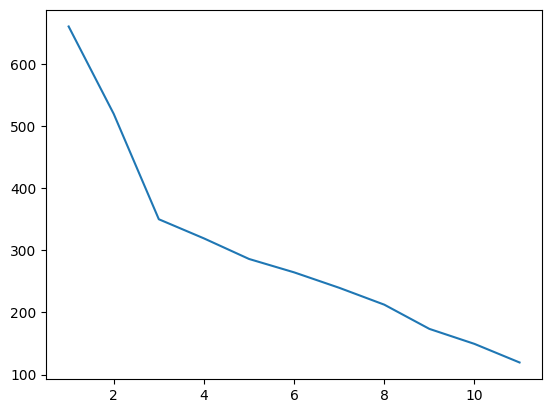

In [25]:
plt.plot(ks, costs)
# choose to use 4

We see from the elbow-plot that 3 is the ideal number of clusters.
We run the clustering algorithm, 
and then print lists of the countries in each cluster by refering back
to our dataframe.

In [26]:
kmeans = KMeans(init="k-means++", n_clusters=3, random_state=0)
kmeans.fit(X_scaled) # for the k means model
cost = kmeans.inertia_
# Get the cluster labels for each point
labels = kmeans.labels_

# group countries by cluster
for cluster_id in range(kmeans.n_clusters):
    countries_in_cluster = df_clean[kmeans.labels_ == cluster_id]['country'].tolist()
    print(f"Cluster {cluster_id}: {', '.join(countries_in_cluster)}")


Cluster 0: Spain, Greece, Israel, Italy
Cluster 1: United Arab Emirates, Bahrain, Kuwait, Oman, Qatar, Saudi Arabia
Cluster 2: Algeria, Egypt, Arab Rep., Iran, Islamic Rep., Iraq, Jordan, Lebanon, Libya, Morocco, Syrian Arab Republic, Tunisia, Turkiye, Yemen, Rep.


## PCA and visualization

Next, we perform principle component analysis to visualize our results in
two dimensions. We use boolean masking to plot each cluster in a different
color.

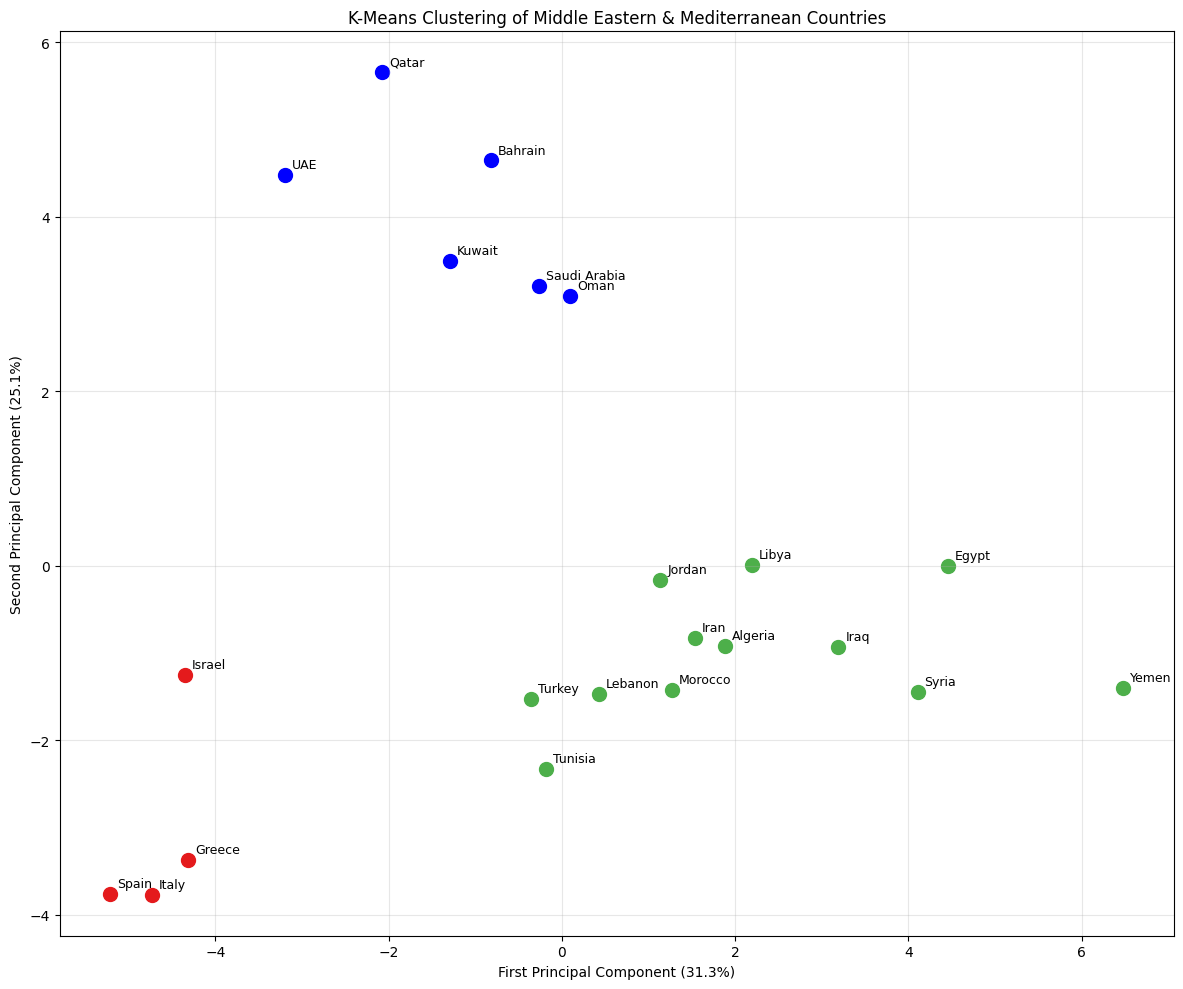

In [27]:
# use PCA to visualize in two dimensions
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize = (12, 10))
    
colors = ['#e41a1c', 'blue', '#4daf4a', 'black']
    
for cluster_id in range(4):
    # get indices of countries in this cluster
    mask = kmeans.labels_ == cluster_id
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
               c=colors[cluster_id], 
               s=100,
               label=f'Cluster {cluster_id}')
    
    # add country name labels
    for idx in numpy.where(mask)[0]:
        ax.annotate(country_codes[df_clean['country_code'].iloc[idx]], 
                   (X_2d[idx, 0], X_2d[idx, 1]),
                   textcoords="offset points",
                   xytext=(5, 5),
                   fontsize=9)

ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_title('K-Means Clustering of Middle Eastern & Mediterranean Countries')
plt.tight_layout()
# add a grid
ax.grid(True, alpha=0.3)
# add percentage of variance to axis labels
ax.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()
    

In [28]:
print(f"Variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

Variance explained: 56.4%


We now check to the extent to which the two-dimension representation accurately
depicts the data. We do this by printing the explained variance in the PCA
object. The two principal components explain 56.4% of the total variance, meaning the 2D visualization captures roughly 60% of the information in the original 32-dimensional dataset. This is less than 2/3 of the information: apparent  inconsistencies in the plot should be interpreted with this limitation in mind.

In [29]:
# get the feature names
feature_names = [col for col in df_clean.columns 
                 if col not in ['country', 'country_code', 'world_region']]

# create a dataframe showing the linear combinations
pca_components = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PC1', 'PC2']
)

# show the largest contributors to each component
print("Top contributors to PC1:")
print(pca_components.loc['PC1'].sort_values().head(7))  # most negative
print(pca_components.loc['PC1'].sort_values().tail(5))  # most positive

print('\n')

print("Top contributors to PC2:")
print(pca_components.loc['PC2'].sort_values().head(7))  # most negative
print(pca_components.loc['PC2'].sort_values().tail(5))  # most positive

Top contributors to PC1:
life_expectancy                -0.311761
human_development_index        -0.290221
corruption_perceptions_index   -0.267747
physicians_per_1000            -0.227290
gdp_per_capita                 -0.223565
gender_equality                -0.220283
urban_population               -0.212688
Name: PC1, dtype: float64
colonial_history    0.177087
political_rights    0.219055
civil_liberties     0.231608
fertility_rate      0.254035
infant_mortality    0.292689
Name: PC1, dtype: float64


Top contributors to PC2:
democracy_score       -0.290164
unemployment          -0.279518
arable_land_pct       -0.270133
avg_rainfall_mm       -0.253190
gender_equality       -0.194890
population            -0.142688
physicians_per_1000   -0.139411
Name: PC2, dtype: float64
cereal_yield             0.213900
political_rights         0.232163
food_production_index    0.277579
air_pollution_pm25       0.306317
co2_per_capita           0.314106
Name: PC2, dtype: float64


Looking at the resultant graph, we can sort the countries into four groups:
Cluster 0 (Spain, Greece, Israel, Italy): These are Mediterranean countries that are the most developed, 'first world' states. They are the most 'Western' out of the countries present. It is interesting to note that Israel is grouped with the European countries despite its geographical location.
Cluster 1 (United Arab Emirates, Bahrain, Kuwait, Oman, Qatar, Saudi Arabia): These are the states of the Arabian peninsula. They are known for having oil and lacking rain--desert countries with low amounts of arable land but stronger economies.
Cluster 2 (Algeria, Egypt, Iran, Iraq, Jordan, Lebanon, Libya, Morocco, Syria, Tunisia, Turkiye, Yemen): These are the remaining Middle Eastern states, known for instability and tumultuous development. Their high position on the first principal axis and low on the second affirms this, with low life expectancy and human development alongside high infant mortality and low political rights. Yemen belongs to this group, despite geographically belonging to cluster 1, because its internal war and instability have led to decreased human development and rampid poverty, uncommon in the oil-rich gulf.

Because the two-dimensional visualization explains only about half the variance in the data, we do not have strong evidence for the factor that typify these groups. However, we can observe that the classification is perhaps not so surprising based on common politicla understandings of the Mediterranean and Middle East.